# Problem Set 5: APIs & SQL


Check out the in-class acitivity notebooks, lecture notebooks, and lecture slides for resources.

0.0 Import packages

**Note you need to install some of the packages imported below (see the comments).**

In [45]:
## helpful packages
import pandas as pd
import numpy as np
import random
import re
import string
import requests
import matplotlib.pyplot as plt
import plotnine 
from plotnine import *
import yaml
#import warnings
#warnings.filterwarnings("ignore")

## note: you may need to install these packages
#! conda activate qss20
#! conda install mysql-connector-python
import mysql.connector

## sklearn imports
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

## print mult things
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

def load_creds(path: str):
    with open(path, 'r') as stream:
        try:
            creds = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)
    return(creds)

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

# 1. Write a wrapper function to pull data from the NAEP API (12 points)

In the class activity on APIs, we practiced pulling from the API for the National Assessment of Educational Progress (NAEP), "America's report card" of test scores. We pulled a small amount of data at the national level (writing scores by gender) using a query where the parameters were hardcoded.
    
In this problem, we'll practice pulling a larger set of data and writing a wrapper function.
    
As a reminder, the documentation is here: https://www.nationsreportcard.gov/api_documentation.aspx

The base link is: https://www.nationsreportcard.gov/Dataservice/GetAdhocData.aspx

## 1.1 Write a query to pull 8th-grade mathematics scores in 2015 from the state of California (CA) by gender (1 point)

- Subject: mathematics 
- Subscale: MRPCM composite scale 
- Grade: 8
- Year: 2015
- grouping variable: GENDER 
- Jurisdiction: CA 
- stattype = MN (for mean)

Print the output in dataframe format and briefly interpret; what do scores look like between the genders?

In [46]:
# defining url
base_url = "https://www.nationsreportcard.gov/DataService/GetAdhocData.aspx"

# defining paramters
params = {
    "type": "data",
    "subject": "mathematics",
    "grade": "8",
    "subscale": "MRPCM",
    "variable": "GENDER",
    "jurisdiction": "CA",
    "stattype": "MN:MN",
    "Year": "2015"
}

response = requests.get(base_url, params=params)
data = response.json()

print(data)   

# Interpretation: In 2015, 8th grade female students in
# California scored slightly higher in mathematics than male students. Female
# students scored ~275.64 while male students scored ~275.02.

{'status': 200, 'serviceVersion': '10.24.2025.2', 'dwellTimeMS': '353.011', 'avgWebHostCPUTotalLoad': 'N/A', 'dataHitType': 'FROM_DATABASE', 'Source': 'B11A', 'result': [{'year': 2015, 'sample': 'R3', 'yearSampleLabel': '2015', 'Cohort': 2, 'CohortLabel': 'Grade 8', 'stattype': 'MN:MN', 'subject': 'MAT', 'grade': 8, 'scale': 'MRPCM', 'jurisdiction': 'CA', 'jurisLabel': 'California', 'variable': 'GENDER', 'variableLabel': 'Sex', 'varValue': '1', 'varValueLabel': 'Male', 'value': 275.020976636682, 'isStatDisplayable': 1, 'errorFlag': 0}, {'year': 2015, 'sample': 'R3', 'yearSampleLabel': '2015', 'Cohort': 2, 'CohortLabel': 'Grade 8', 'stattype': 'MN:MN', 'subject': 'MAT', 'grade': 8, 'scale': 'MRPCM', 'jurisdiction': 'CA', 'jurisLabel': 'California', 'variable': 'GENDER', 'variableLabel': 'Sex', 'varValue': '2', 'varValueLabel': 'Female', 'value': 275.638637274477, 'isStatDisplayable': 1, 'errorFlag': 0}]}


## 1.2 Write a query to pull 8th-grade mathematics scores in 2013, 2015, 2017, and 2019 from California by gender (1 point)

Same as 1.1 but pull the years 2013, 2015, 2017, and 2019 (search documentation for how to combine) in one query

In [47]:
base_url = "https://www.nationsreportcard.gov/DataService/GetAdhocData.aspx"

params = {
    "type": "data",
    "subject": "mathematics",
    "grade": "8",
    "subscale": "MRPCM",
    "variable": "GENDER",
    "jurisdiction": "CA",
    "stattype": "MN:MN",
    "Year": "2013,2015,2017,2019"
}

response = requests.get(base_url, params=params)
data = response.json()

df = pd.DataFrame(data["result"])
df

,year,sample,yearSampleLabel,Cohort,CohortLabel,stattype,subject,grade,scale,jurisdiction,jurisLabel,variable,variableLabel,varValue,varValueLabel,value,isStatDisplayable,errorFlag
0,2013,R3,2013,2,Grade 8,MN:MN,MAT,8,MRPCM,CA,California,GENDER,Sex,1,Male,277.167171,1,0
1,2013,R3,2013,2,Grade 8,MN:MN,MAT,8,MRPCM,CA,California,GENDER,Sex,2,Female,274.597824,1,0
2,2015,R3,2015,2,Grade 8,MN:MN,MAT,8,MRPCM,CA,California,GENDER,Sex,1,Male,275.020977,1,0
3,2015,R3,2015,2,Grade 8,MN:MN,MAT,8,MRPCM,CA,California,GENDER,Sex,2,Female,275.638637,1,0
4,2017,R3,2017,2,Grade 8,MN:MN,MAT,8,MRPCM,CA,California,GENDER,Sex,1,Male,276.608704,1,0
5,2017,R3,2017,2,Grade 8,MN:MN,MAT,8,MRPCM,CA,California,GENDER,Sex,2,Female,276.669430,1,0
6,2019,R3,2019,2,Grade 8,MN:MN,MAT,8,MRPCM,CA,California,GENDER,Sex,1,Male,274.511628,1,0
7,2019,R3,2019,2,Grade 8,MN:MN,MAT,8,MRPCM,CA,California,GENDER,Sex,2,Female,276.721824,1,0


## 1.3 Create a line plot to show variation in the scores across years (2 points)

Using the results from 1.2, create a plot where the x axis has the year and the y axis is the math scores (`value` in dataframe), and there are separate lines/colors for male versus female students (`varValueLabel` in dataframe)

Start the limits of the y axis minimum at 272 and add informative labels. Be sure your x-axis is ticked on odd years, because NAEP scores skip even years. 

<Figure size 640x480 with 0 Axes>

(272.0, 277.29994776969266)

([<matplotlib.axis.XTick at 0x169072150>,
 [Text(2013, 0, '2013'),
  Text(2015, 0, '2015'),
  Text(2017, 0, '2017'),
  Text(2019, 0, '2019')])

Text(0.5, 0, 'Year')

Text(0, 0.5, 'Math Score (NAEP Value)')

Text(0.5, 1.0, 'Grade 8 NAEP Math Scores in CA by Gender')

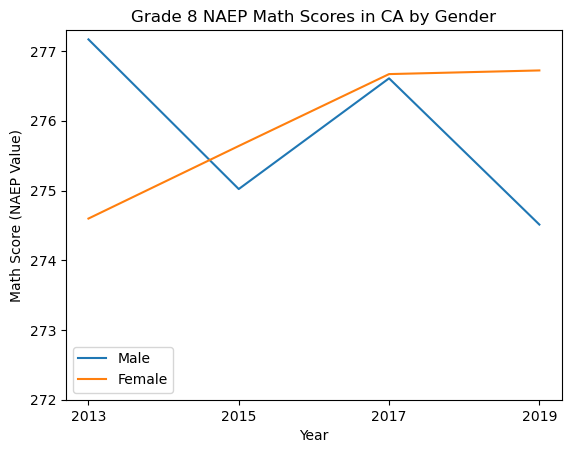

In [48]:
plt.figure()

for gender in df["varValueLabel"].unique():
    subset = df[df["varValueLabel"] == gender]
    plt.plot(subset["year"], subset["value"], label=gender)

plt.ylim(bottom=272)
plt.xticks([2013, 2015, 2017, 2019])
plt.xlabel("Year")
plt.ylabel("Math Score (NAEP Value)")
plt.title("Grade 8 NAEP Math Scores in CA by Gender")
plt.legend()
plt.show()

## 1.4 Reproduce the queries from 1.1 and 1.2 using a user-defined function (4 points)

Create a function, `construct_naep_query` that takes in two arguments:

- year: this should be a list with all years (so if one year, single element list; if multiple years, list with those years)
- place: this should be a string with the name of the state or jurisdiction to pull 
    
Have the function return the query and make sure it's identical to the queries you wrote for 1.1 and 1.2 (can use assert or other checker)

In [49]:
def construct_naep_query(years, place):
    year_str = ",".join(str(y) for y in years)  # convert list of years to comma-separated string
    params = {
        "type": "data",
        "subject": "mathematics",
        "grade": "8",
        "subscale": "MRPCM",
        "variable": "GENDER",
        "jurisdiction": place,
        "stattype": "MN:MN",
        "Year": year_str
    }
    
    return params
print(construct_naep_query([2015], "CA"))
print(construct_naep_query([2013,2015,2017,2019], "CA"))


{'type': 'data', 'subject': 'mathematics', 'grade': '8', 'subscale': 'MRPCM', 'variable': 'GENDER', 'jurisdiction': 'CA', 'stattype': 'MN:MN', 'Year': '2015'}
{'type': 'data', 'subject': 'mathematics', 'grade': '8', 'subscale': 'MRPCM', 'variable': 'GENDER', 'jurisdiction': 'CA', 'stattype': 'MN:MN', 'Year': '2013,2015,2017,2019'}


In [50]:
expected_1_1 = {
    "type": "data",
    "subject": "mathematics",
    "grade": "8",
    "subscale": "MRPCM",
    "variable": "GENDER",
    "jurisdiction": "CA",
    "stattype": "MN:MN",
    "Year": "2015"
}
assert construct_naep_query([2015], "CA") == expected_1_1


expected_1_2 = {
    "type": "data",
    "subject": "mathematics",
    "grade": "8",
    "subscale": "MRPCM",
    "variable": "GENDER",
    "jurisdiction": "CA",
    "stattype": "MN:MN",
    "Year": "2013,2015,2017,2019"
}
assert construct_naep_query([2013,2015,2017,2019], "CA") == expected_1_2

## 1.5 Write and execute user-defined function that takes in a query and returns a pandas dataframe with the content of the response (4 points)

- Write a user-defined function (`process_naep_query`) that takes in the CA-specific NAEP query as a string, calls the API, and transforms the response into a pandas dataframe. Have the function return that pandas dataframe

- Make sure the function is flexible enough to handle queries that return an error; for queries that return an error, have the function return the string "Data not found; check your query" (see the solution for the in-class activity for API Part 1 for an example of `try:`/`except:`)

- Execute the function on the query that pulls 2013-2019 data (either from handwriting the query or the result in 1.4)

- Print the resulting dataframe

- Then execute the function on a query that pulls a state that doesn't exist (call this state ZZ)

In [51]:
def process_naep_query(query_params):
    try:
        response = requests.get(base_url, params=query_params)
        data = response.json()
        if data.get("statusCode") == 400 or data.get("status") != 200:
            return "Data not found; check your query"
        df = pd.DataFrame(data["result"])
        return df
    except:
        return "Data not found; check your query"

query_2013_2019 = construct_naep_query([2013,2015,2017,2019], "CA")
df_2013_2019 = process_naep_query(query_2013_2019)
print(df_2013_2019)

query_invalid = construct_naep_query([2015], "ZZ")
df_invalid = process_naep_query(query_invalid)
print(df_invalid)

   year sample yearSampleLabel  Cohort CohortLabel stattype subject  grade  scale jurisdiction  jurisLabel variable variableLabel varValue varValueLabel       value  isStatDisplayable  errorFlag
0  2013     R3            2013       2     Grade 8    MN:MN     MAT      8  MRPCM           CA  California   GENDER           Sex        1          Male  277.167171                  1          0
1  2013     R3            2013       2     Grade 8    MN:MN     MAT      8  MRPCM           CA  California   GENDER           Sex        2        Female  274.597824                  1          0
2  2015     R3            2015       2     Grade 8    MN:MN     MAT      8  MRPCM           CA  California   GENDER           Sex        1          Male  275.020977                  1          0
3  2015     R3            2015       2     Grade 8    MN:MN     MAT      8  MRPCM           CA  California   GENDER           Sex        2        Female  275.638637                  1          0
4  2017     R3           

# 2. Explore data using SQL queries (18 points)

In the previous example, you worked with the data in a flat file and manipulated it using pandas. Here, we're going to practice running queries to do some calculations using SQL --- in the case of our data, this is a bit overkill since the data are small but it is practice for larger datasets.

## 2.1 Load database credentials and establish a connection (1 point)

Prep work: Authorize connection to our own SQL database

1. Copy the credential file for the in-class activity for SQL (`lecXX_db_cred.yaml`) to the folder containing your problem set notebook
2. Rename the combined credential file something appropriate (feel free to get creative)
3. Change the database name in the credential file from `sentencing` to `math_gencompare` to connect to the `math_gencompare` database
4. Load the credential file.  You'll need it to connect to the `math_gencompare` database (see how to do this in the activity for SQL)

Note: To establish the SQL connection, you need to be on `eduroam` (near campus) or the Dartmouth's GlobalProtect VPN  ([installation instructions here](https://services.dartmouth.edu/TDClient/1806/Portal/KB/ArticleDet?ID=72395))

In [52]:
creds = load_creds("math_stuff.yaml")

cnx = mysql.connector.connect(
    user=creds['practice_database']['user'],
    password=creds['practice_database']['password'],
    port=creds['practice_database']['port'],
    database=creds['practice_database']['database'],
    host=creds['practice_database']['host']
)
cnx

## 2.2 Run a query to select all columns and the first 5 rows of the math_gencompare database to explore structure (2 points)

Read the results in as a pandas dataframe and print the result

In [53]:
## define a query to pull first 5 rows from caseinit table
query = """
SELECT * 
FROM math_gencompare 
LIMIT 5;
"""
df = pd.read_sql(query, cnx)
print(df)


  abbrev  FIPS       state  year            female              male
0     AK     2      Alaska  2013  281.388243030547  281.723376175464
1     AL     1     Alabama  2013  268.920111754346  269.457455785562
2     AR     5    Arkansas  2013  278.381788404903  277.457662328569
3     AZ     4     Arizona  2013  279.249581150207  280.174388600923
4     CA     6  California  2013  274.597823860242  277.167170641967


/var/folders/k9/0k40031s4q9btj5wvqclnww00000gn/T/ipykernel_12624/2058197602.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.


## 2.3 Find the (1) number of rows in the database, (2) number of distinct states,  (3) number of distinct years (3 points)

Interpret the results - how do you think the data is structured in terms of states and years (eg long format where each state repeated; wide format)?

**Hint**: rather than using count `(*)` for the latter two, think about the `distinct` command in combination with `count`: https://www.w3resource.com/mysql/aggregate-functions-and-grouping/aggregate-functions-and-grouping-count-with-distinct.php

In [54]:
# number of rows in the database:
query_rows = """
SELECT COUNT(*)
AS total_rows
FROM math_gencompare
"""

df_rows = pd.read_sql(query_rows, cnx)
print(df_rows)

#number of distinct states in the database:
query_unique_states = """
SELECT COUNT(DISTINCT state)
AS distinct_states
FROM math_gencompare
"""

df_unique_states = pd.read_sql(query_unique_states, cnx)
print(df_unique_states)


# number of distinct years:
query_unique_years = """
SELECT COUNT(DISTINCT year)
AS distinct_years
FROM math_gencompare
"""

df_unique_years = pd.read_sql(query_unique_years, cnx)
print(df_unique_years)

#interpretation:
# This data appears to be in long format because each row represents one observation.
# With 50 distinct states and 4 distinct years, htere are 200 total rows, suggesting that
# each state has multiple rows corresponding to different years.

   total_rows
0         200
   distinct_states
0               50
   distinct_years
0               4


/var/folders/k9/0k40031s4q9btj5wvqclnww00000gn/T/ipykernel_12624/3271704439.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
/var/folders/k9/0k40031s4q9btj5wvqclnww00000gn/T/ipykernel_12624/3271704439.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
/var/folders/k9/0k40031s4q9btj5wvqclnww00000gn/T/ipykernel_12624/3271704439.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.


## 2.4 Construct a new variable, `is_male_higher` that takes the value of 1 if the math scores of males exceed that of females in that state and year (each row) (2 points)

Read in the results, print the head, and find the mean across all rows (the percentage of state-years where male students have higher scores)

In [55]:
is_male_higher = """
SELECT *,
       CASE
           WHEN male > female THEN 1
           ELSE 0 END 
       AS is_male_higher
FROM math_gencompare;
"""
df_male_higher = pd.read_sql_query(is_male_higher, cnx)
print(df_male_higher.head())

pct_male_higher = """
SELECT AVG(CASE WHEN male > female THEN 1
 ELSE 0 END) 
AS pct_male_higher
FROM math_gencompare;
"""

df_pct = pd.read_sql_query(pct_male_higher, cnx)
print(df_pct)


  abbrev  FIPS       state  year            female              male  is_male_higher
0     AK     2      Alaska  2013  281.388243030547  281.723376175464               1
1     AL     1     Alabama  2013  268.920111754346  269.457455785562               1
2     AR     5    Arkansas  2013  278.381788404903  277.457662328569               0
3     AZ     4     Arizona  2013  279.249581150207  280.174388600923               1
4     CA     6  California  2013  274.597823860242  277.167170641967               1
   pct_male_higher
0            0.515


/var/folders/k9/0k40031s4q9btj5wvqclnww00000gn/T/ipykernel_12624/2672445174.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
/var/folders/k9/0k40031s4q9btj5wvqclnww00000gn/T/ipykernel_12624/2672445174.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.


## 2.5 group by year and find the percentage of states where male scores are higher than females (4 points)

**A.** Write a query that (1) groups by year and (2) finds the percentage of states that have higher scores for males than females in this year 

**B.** Print the resulting dataframe and interpret the results 

**Hint:** To compare male and female scores, consider logical operators (e.g., `<`, `>`, `=`) and simple aggregation (e.g., `avg()` to get mean) or using a subquery to construct the indicator.

In [56]:
query_male_higher_by_year = """
SELECT year, 
AVG(CASE
    WHEN male > female THEN 1
    ELSE 0 END)
    AS percent_male_higher
FROM math_gencompare
GROUP BY year
ORDER BY year;
"""

male_higher_by_year_df = pd.read_sql(query_male_higher_by_year, cnx)
print(male_higher_by_year_df)

# interpret: In 2013 to 2017, more than half the states had higher scores for males
# than for females. But by 2019, onlt 30% of states had higher male scores.
# Thi means females started outperforming males in most states in 2019.

   year  percent_male_higher
0  2013                 0.62
1  2015                 0.56
2  2017                 0.58
3  2019                 0.30


/var/folders/k9/0k40031s4q9btj5wvqclnww00000gn/T/ipykernel_12624/2876647762.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.


## 2.6 group by state and find the percentage of years where male scores higher than females

**A.** Write a query that (1) groups by state and (2) finds the percentage of years that have higher scores for males than females in that state

**B.** Plot the results ordering the states from males higher all 4 years to males higher none of the years

In [57]:
query_male_higher_year_pct = """
SELECT state, AVG(CASE
    WHEN male > female THEN 1
    ELSE 0 END)
AS  percent_male_higher
FROM math_gencompare
GROUP BY state
ORDER BY percent_male_higher DESC;
"""
state_percent_df = pd.read_sql(query_male_higher_year_pct, cnx)
print(state_percent_df.head())

           state  percent_male_higher
0           Utah                 1.00
1       Illinois                 1.00
2          Idaho                 1.00
3         Alaska                 0.75
4  New Hampshire                 0.75


/var/folders/k9/0k40031s4q9btj5wvqclnww00000gn/T/ipykernel_12624/3495777983.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.


## 2.7 Use a subquery to create an indicator and group by that indicator (6 points)

The following states were the first 6 to expand the right to vote to women before the uniform federal expansion in 1920

- Wyoming 1890
- Colorado 1893
- Utah 1896
- Idaho 1896
- Washington 1910
- California 1911

**A.** Create an indicator `is_early_voter` for whether a state is in that list or not; do so without typing the state names inside the string and instead collapsing the list of states we provide and using something like `format`. Hint on how to combine the state names while preserving the quotes around each: https://stackoverflow.com/questions/12007686/join-a-list-of-strings-in-python-and-wrap-each-string-in-quotation-marks 

**B.** Then, group by the `is_early_voter` indicator and `year` and find the percencentage of states in each group where males had higher scores than females 

**C.** Print the resulting dataframe and interpret. Does early expansion of voting seem to be correlated with girls scoring better on the math tests a century later?

**Hint:** in order to group by the indicator in step b, you may need to use a subquery 

In [58]:
## list of states we provide
list_suffrage = ["Wyoming", "Colorado", "Utah", "Idaho", "Washington", 
                "California"]


In [ ]:
states_string = ", ".join([f"'{state}'" for state in list_suffrage])

query_early_voter = f"""
SELECT is_early_voter, year, AVG(CASE 
        WHEN male > female THEN 1 
        ELSE 0 END) 
        AS percent_male_higher
FROM (
    SELECT *,
        CASE WHEN state IN ({states_string}) THEN 1
            ELSE 0 END 
            AS is_early_voter
    FROM math_gencompare
) AS sub
GROUP BY is_early_voter, year
ORDER BY is_early_voter, year;
"""

early_voter_df = pd.read_sql(query_early_voter, cnx)
print(early_voter_df)

# interpret
# States that got suffrage earlier still consististantly have higher percentage 
# of male math scores, suggesting there isnt evidecne of early expansion being 
# associated with girl performing better in math.

   is_early_voter  year  percent_male_higher
0               0  2013               0.5909
1               0  2015               0.5455
2               0  2017               0.5455
3               0  2019               0.2727
4               1  2013               0.8333
5               1  2015               0.6667
6               1  2017               0.8333
7               1  2019               0.5000


/var/folders/k9/0k40031s4q9btj5wvqclnww00000gn/T/ipykernel_12624/4128298537.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
